In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [17]:
df_optim_cosim = pd.read_csv("DAC_optimal_simulation_results_testing.csv")

In [18]:
df_optim_cosim

,caco3_flow_rate [kmol/hr],calciner_temp [Deg C],pellet_moisture_frac,air_mol_flow_rate [kmol/hr],RH_air,DAC_column_height [m],pellet_diameter [mm],DAC_ambient_temp [Deg C],e_voidage,capture_efficiency_%,...,Simulation_status,Failure_reason,Heat_duty[cal/sec],Brake_power[kW],calcium_hydroxide_pellet[kmol_per_hr],SCM_conversion_fraction,Ca(OH)2_conversion,mass_flow_co2_in[kg/hr],mass_flow_co2_out[kg/hr],DAC_inlet_press[atm]
0,97.863788,919.904840,0.064531,7118.821754,0.870483,9.997187,1.049191,42.714769,0.353125,65.621880,...,Success,NaN,1.457212e+06,17913.0026,122.153747,0.976727,0.029466,129.933354,3.023947,4.742487
1,97.924051,919.904840,0.064555,7118.821754,0.870483,9.997187,1.049191,42.716989,0.353125,65.621880,...,Success,NaN,1.458110e+06,17913.0905,122.237356,0.976974,0.029455,129.933354,2.991797,4.742516
2,97.832777,919.696195,0.064504,7117.219329,0.872091,9.999902,1.059883,43.707146,0.353171,65.603966,...,Success,NaN,1.456600e+06,17828.4877,122.105594,0.964936,0.029120,129.933354,4.555988,4.714537
3,97.837663,919.099393,0.064516,7114.636077,0.870726,9.995373,1.059244,43.733019,0.353064,65.585068,...,Success,NaN,1.456242e+06,17851.8849,122.115774,0.963974,0.029089,129.933354,4.681037,4.722263
4,97.898044,919.696195,0.064609,7045.451161,0.870730,9.995326,1.060114,43.722263,0.353059,65.578468,...,Success,NaN,1.457572e+06,17830.2229,122.223889,0.963410,0.029054,129.933354,4.754213,4.715110
5,97.621017,919.402894,0.065140,7041.773748,0.872018,9.996710,1.045518,43.740941,0.353145,65.559578,...,Success,NaN,1.453236e+06,17942.9735,122.063365,0.981104,0.029672,129.933354,2.455183,4.752427
6,97.806708,919.733927,0.064599,7117.490152,0.870721,9.999612,1.057005,43.717158,0.353101,65.603966,...,Success,NaN,1.456239e+06,17872.1426,122.106236,0.966676,0.029180,129.933354,4.329906,4.728959
7,97.667482,919.694791,0.064772,7042.829655,0.898222,9.966109,1.047911,43.729616,0.353064,65.494453,...,Failure,"(-2147352567, 'Exception occurred.', (14, 'VAS...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,97.904062,919.841700,0.064597,7044.707805,0.870339,9.999844,1.060147,43.717158,0.353101,65.578468,...,Success,NaN,1.457766e+06,17833.3703,122.227054,0.963125,0.029044,129.933354,4.791345,4.716149
9,97.837736,919.099393,0.064516,7105.147999,0.870726,9.995367,1.059244,43.733019,0.353064,65.585068,...,Success,NaN,1.456243e+06,17849.9712,122.115865,0.964012,0.029090,129.933354,4.676003,4.721631


In [19]:
#Converting Cal/sec to KW
df_optim_cosim["Heat_duty[cal/sec]"] = abs(df_optim_cosim["Heat_duty[cal/sec]"] * 0.004184)
#renaming column to Heat_duty[KW]
df_optim_cosim= df_optim_cosim.rename(columns= {"Heat_duty[cal/sec]": "Heat_duty[KW]"})
df_optim_cosim.head()

,caco3_flow_rate [kmol/hr],calciner_temp [Deg C],pellet_moisture_frac,air_mol_flow_rate [kmol/hr],RH_air,DAC_column_height [m],pellet_diameter [mm],DAC_ambient_temp [Deg C],e_voidage,capture_efficiency_%,...,Simulation_status,Failure_reason,Heat_duty[KW],Brake_power[kW],calcium_hydroxide_pellet[kmol_per_hr],SCM_conversion_fraction,Ca(OH)2_conversion,mass_flow_co2_in[kg/hr],mass_flow_co2_out[kg/hr],DAC_inlet_press[atm]
0,97.863788,919.904840,0.064531,7118.821754,0.870483,9.997187,1.049191,42.714769,0.353125,65.621880,...,Success,NaN,6096.976425,17913.0026,122.153747,0.976727,0.029466,129.933354,3.023947,4.742487
1,97.924051,919.904840,0.064555,7118.821754,0.870483,9.997187,1.049191,42.716989,0.353125,65.621880,...,Success,NaN,6100.730855,17913.0905,122.237356,0.976974,0.029455,129.933354,2.991797,4.742516
2,97.832777,919.696195,0.064504,7117.219329,0.872091,9.999902,1.059883,43.707146,0.353171,65.603966,...,Success,NaN,6094.414524,17828.4877,122.105594,0.964936,0.029120,129.933354,4.555988,4.714537
3,97.837663,919.099393,0.064516,7114.636077,0.870726,9.995373,1.059244,43.733019,0.353064,65.585068,...,Success,NaN,6092.917264,17851.8849,122.115774,0.963974,0.029089,129.933354,4.681037,4.722263
4,97.898044,919.696195,0.064609,7045.451161,0.870730,9.995326,1.060114,43.722263,0.353059,65.578468,...,Success,NaN,6098.480355,17830.2229,122.223889,0.963410,0.029054,129.933354,4.754213,4.715110


In [20]:
#Converting the power units to costs, to reflective value of power
df_optim_cosim["power_cost[$]"] = df_optim_cosim["Brake_power[kW]"] * 0.1778 + df_optim_cosim["Heat_duty[KW]"] * 0.05
#Calculating mass of CO2 captured
df_optim_cosim["mass_co2_captured[kg/hr]"] = df_optim_cosim["mass_flow_co2_in[kg/hr]"] - df_optim_cosim["mass_flow_co2_out[kg/hr]"]
#Calculating Specific Energy Cost per CO2 consumed
df_optim_cosim["SECC"] = df_optim_cosim["power_cost[$]"] / df_optim_cosim["mass_co2_captured[kg/hr]"]

In [21]:
df_optim_cosim

,caco3_flow_rate [kmol/hr],calciner_temp [Deg C],pellet_moisture_frac,air_mol_flow_rate [kmol/hr],RH_air,DAC_column_height [m],pellet_diameter [mm],DAC_ambient_temp [Deg C],e_voidage,capture_efficiency_%,...,Brake_power[kW],calcium_hydroxide_pellet[kmol_per_hr],SCM_conversion_fraction,Ca(OH)2_conversion,mass_flow_co2_in[kg/hr],mass_flow_co2_out[kg/hr],DAC_inlet_press[atm],power_cost[$],mass_co2_captured[kg/hr],SECC
0,97.863788,919.904840,0.064531,7118.821754,0.870483,9.997187,1.049191,42.714769,0.353125,65.621880,...,17913.0026,122.153747,0.976727,0.029466,129.933354,3.023947,4.742487,3489.780684,126.909407,27.498203
1,97.924051,919.904840,0.064555,7118.821754,0.870483,9.997187,1.049191,42.716989,0.353125,65.621880,...,17913.0905,122.237356,0.976974,0.029455,129.933354,2.991797,4.742516,3489.984034,126.941557,27.492841
2,97.832777,919.696195,0.064504,7117.219329,0.872091,9.999902,1.059883,43.707146,0.353171,65.603966,...,17828.4877,122.105594,0.964936,0.029120,129.933354,4.555988,4.714537,3474.625839,125.377366,27.713342
3,97.837663,919.099393,0.064516,7114.636077,0.870726,9.995373,1.059244,43.733019,0.353064,65.585068,...,17851.8849,122.115774,0.963974,0.029089,129.933354,4.681037,4.722263,3478.710998,125.252317,27.773626
4,97.898044,919.696195,0.064609,7045.451161,0.870730,9.995326,1.060114,43.722263,0.353059,65.578468,...,17830.2229,122.223889,0.963410,0.029054,129.933354,4.754213,4.715110,3475.137649,125.179141,27.761316
5,97.621017,919.402894,0.065140,7041.773748,0.872018,9.996710,1.045518,43.740941,0.353145,65.559578,...,17942.9735,122.063365,0.981104,0.029672,129.933354,2.455183,4.752427,3494.277672,127.478171,27.410792
6,97.806708,919.733927,0.064599,7117.490152,0.870721,9.999612,1.057005,43.717158,0.353101,65.603966,...,17872.1426,122.106236,0.966676,0.029180,129.933354,4.329906,4.728959,3482.312181,125.603448,27.724654
7,97.667482,919.694791,0.064772,7042.829655,0.898222,9.966109,1.047911,43.729616,0.353064,65.494453,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,97.904062,919.841700,0.064597,7044.707805,0.870339,9.999844,1.060147,43.717158,0.353101,65.578468,...,17833.3703,122.227054,0.963125,0.029044,129.933354,4.791345,4.716149,3475.737978,125.142009,27.774350
9,97.837736,919.099393,0.064516,7105.147999,0.870726,9.995367,1.059244,43.733019,0.353064,65.585068,...,17849.9712,122.115865,0.964012,0.029090,129.933354,4.676003,4.721631,3478.370969,125.257351,27.769795


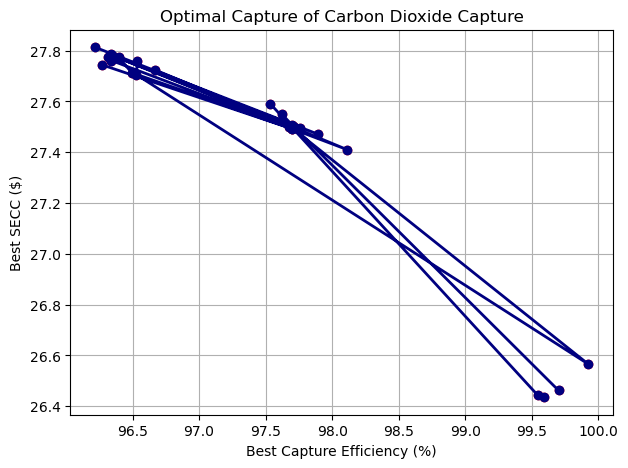

In [81]:
#PLot the optimization results
plt.figure(figsize=(7, 5))
plt.scatter(df_optim_cosim["SCM_conversion_fraction"] * 100, df_optim_cosim["SECC"], color="red")
plt.plot(df_optim_cosim["SCM_conversion_fraction"] * 100, df_optim_cosim["SECC"], "o-", color='navy', label='Pareto Frontier', linewidth=2)

plt.title("Optimal Capture of Carbon Dioxide Capture")
plt.xlabel("Best Capture Efficiency (%)")
plt.ylabel("Best SECC ($)")
plt.grid(True)

Text(0, 0.5, 'heterogenuous SECC ($)')

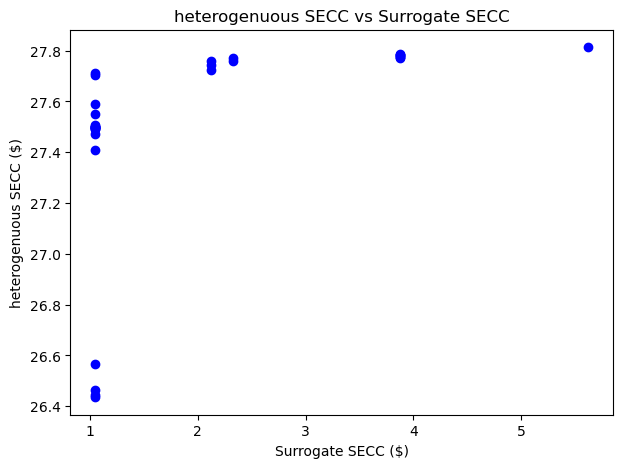

In [71]:
#PLot the optimization results
plt.figure(figsize=(7, 5))
plt.scatter(df_optim_cosim["SECC_$"].sort_values(), df_optim_cosim["SECC"].sort_values(), color="blue")
plt.title("heterogenuous SECC vs Surrogate SECC")
plt.xlabel("Surrogate SECC ($)")
plt.ylabel("heterogenuous SECC ($)")

In [28]:
#Pareto curve with optimization results
df_pareto =  pd.read_csv("pareto_points.csv")

In [29]:
df_pareto

,caco3_flow_rate [kmol/hr],calciner_temp [Deg C],pellet_moisture_frac,air_mol_flow_rate [kmol/hr],RH_air,DAC_column_height [m],pellet_diameter [mm],DAC_ambient_temp [Deg C],e_voidage,capture_efficiency_%,SECC_$
0,97.640591,947.125303,0.333040,8829.740466,0.898318,9.155514,1.019511,43.741866,0.355758,49.815746,-13.835405
1,97.645531,947.125303,0.333210,8829.728139,0.897813,9.165189,1.015949,43.742928,0.355754,49.815746,-13.835405
2,97.863788,919.904840,0.064531,7118.821754,0.870483,9.997187,1.049191,42.714769,0.353125,65.621880,10.950542
3,97.924051,919.904840,0.064555,7118.821754,0.870483,9.997187,1.049191,42.716989,0.353125,65.621880,10.950542
4,97.805738,947.120714,0.332511,8829.607155,0.899936,9.293540,1.001176,43.761773,0.355763,51.707901,-13.594645
...,...,...,...,...,...,...,...,...,...,...,...
995,97.892645,944.528936,0.064775,8915.727909,0.892891,9.984907,1.046664,43.769653,0.380992,59.395931,-10.678812
996,97.907560,944.886496,0.064511,7042.643146,0.892316,9.812477,1.048009,43.756998,0.381138,60.687401,-8.773365
997,97.659999,944.685925,0.266191,7044.871356,0.899489,9.969269,1.010119,43.779125,0.353143,63.423153,-3.091374
998,97.852300,944.900236,0.064534,7040.659885,0.891516,9.999207,1.021857,43.734374,0.381133,60.570187,-9.104662


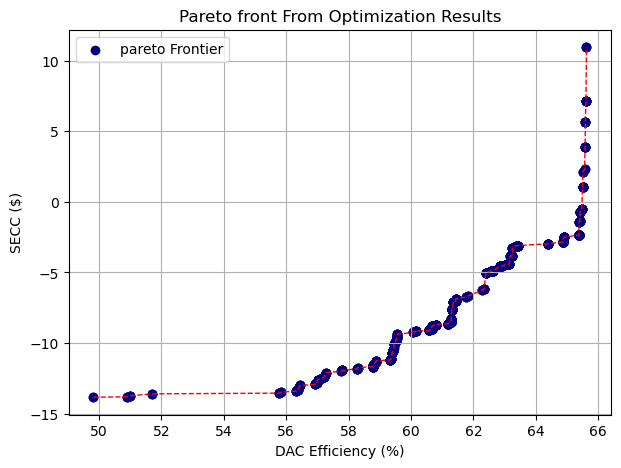

In [211]:
from scipy.interpolate import make_interp_spline, make_smoothing_spline
import numpy as np

plt.figure(figsize=(7, 5))
# Sort points
points = sorted(zip(df_pareto["capture_efficiency_%"], df_pareto["SECC_$"]))
x, y= zip(*points)

plt.scatter(df_pareto["capture_efficiency_%"], df_pareto["SECC_$"], color="navy", label="pareto Frontier")

# 3. Plot
plt.plot(x, y, color='red', linewidth=1, linestyle="--")
# plt.scatter( df_optim_cosim["SCM_conversion_fraction"] * 100, df_optim_cosim["SECC"], color='red', marker='*', s=100, label='Validated (Rerun)')
plt.title("Pareto front From Optimization Results")
plt.xlabel("DAC Efficiency (%)")
plt.ylabel("SECC ($)")
plt.grid(True)
plt.legend();

# 1. Simulation results using LHS values

In [98]:
df_sim_lhs = pd.read_csv("DAC_simulation_results.csv")
df_sim_lhs.head(20)

,caco3_flow_rate [kmol/hr],calciner_temp [Deg C],pellet_moisture_frac,air_mol_flow_rate [kmol/hr],RH_air,DAC_column_height [m],pellet_diameter [mm],DAC_ambient_temp [Deg C],e_voidage,sim_index,Simulation_status,Failure_reason,Heat_duty[cal/sec],Brake_power[kW],calcium_hydroxide_pellet[kmol_per_hr],SCM_conversion_fraction,Ca(OH)2_conversion,mass_flow_co2_in[kg/hr],mass_flow_co2_out[kg/hr],DAC_inlet_press[atm]
0,97.514977,921.285152,0.493512,8833.277513,0.801022,4.919290,3.805631,21.742198,0.439079,0.0,Success,NaN,1.453011e+06,3315.32380,197.732350,0.065231,0.001975,129.933354,121.457616,1.425452
1,31.906558,939.507047,0.333939,8082.465700,0.767765,2.624554,5.462603,34.839420,0.427176,1.0,Success,NaN,4.797141e+05,1585.60372,61.085258,0.018301,0.001693,129.933354,127.555456,1.197886
2,66.419432,929.838273,0.426463,7335.719044,0.836021,1.900874,4.928280,24.921964,0.429412,2.0,Success,NaN,9.938685e+05,1093.61784,133.214233,0.023755,0.001056,129.933354,126.846790,1.138224
3,5.255308,916.227948,0.082039,8304.100432,0.103660,9.760061,4.125589,21.887194,0.418892,3.0,Failure,"(-2147352567, 'Exception occurred.', (14, 'VAS...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,99.038780,900.174052,0.347316,7315.145793,0.575318,9.355005,4.346817,38.664208,0.397470,4.0,Success,NaN,1.460315e+06,6795.42600,191.346494,0.067884,0.002024,129.933354,121.113005,1.974501
5,98.462316,905.306138,0.112064,7753.304554,0.248262,2.872001,1.768148,41.269448,0.434394,5.0,Success,NaN,1.455534e+06,4722.67587,138.745351,0.034217,0.001026,129.933354,125.487452,1.632167
6,50.970918,897.811960,0.094812,7071.693198,0.224262,5.049063,4.746962,28.187152,0.362767,6.0,Success,NaN,7.506748e+05,4697.99006,68.956745,0.021334,0.001236,129.933354,127.161404,1.628367
7,48.633932,895.910834,0.379910,7922.619623,0.541961,1.858839,4.738924,36.894148,0.384417,7.0,Success,NaN,7.155771e+05,2167.55054,95.740298,0.011316,0.000687,129.933354,128.462990,1.271305
8,44.221752,927.241785,0.191522,8824.942938,0.496150,7.016403,3.974741,41.624076,0.428031,8.0,Success,NaN,6.608652e+05,5416.25044,72.374898,0.037756,0.002521,129.933354,125.027638,1.741550
9,74.228539,909.646508,0.373114,7256.322342,0.193025,3.456817,4.966082,21.622874,0.432136,9.0,Success,NaN,1.099666e+06,1906.47574,145.613316,0.010178,0.000405,129.933354,128.610931,1.237981


In [99]:
#Converting Cal/sec to KW
df_sim_lhs["Heat_duty[cal/sec]"] = abs(df_sim_lhs["Heat_duty[cal/sec]"] * 0.004184)
#renaming column to Heat_duty[KW]
df_sim_lhs= df_sim_lhs.rename(columns= {"Heat_duty[cal/sec]": "Heat_duty[KW]"})
#Converting the power units to costs, to reflective value of power
df_sim_lhs["power_cost[$]"] = df_sim_lhs["Brake_power[kW]"] * 0.1778 + df_sim_lhs["Heat_duty[KW]"] * 0.05
#Calculating mass of CO2 captured
df_sim_lhs["mass_co2_captured[kg/hr]"] = df_sim_lhs["mass_flow_co2_in[kg/hr]"] - df_sim_lhs["mass_flow_co2_out[kg/hr]"]
#Calculating Specific Energy Cost per CO2 consumed
df_sim_lhs["SECC"] = df_sim_lhs["power_cost[$]"] / df_sim_lhs["mass_co2_captured[kg/hr]"]
df_sim_lhs.head()

,caco3_flow_rate [kmol/hr],calciner_temp [Deg C],pellet_moisture_frac,air_mol_flow_rate [kmol/hr],RH_air,DAC_column_height [m],pellet_diameter [mm],DAC_ambient_temp [Deg C],e_voidage,sim_index,...,Brake_power[kW],calcium_hydroxide_pellet[kmol_per_hr],SCM_conversion_fraction,Ca(OH)2_conversion,mass_flow_co2_in[kg/hr],mass_flow_co2_out[kg/hr],DAC_inlet_press[atm],power_cost[$],mass_co2_captured[kg/hr],SECC
0,97.514977,921.285152,0.493512,8833.277513,0.801022,4.919290,3.805631,21.742198,0.439079,0.0,...,3315.32380,197.732350,0.065231,0.001975,129.933354,121.457616,1.425452,893.434531,8.475738,105.410825
1,31.906558,939.507047,0.333939,8082.465700,0.767765,2.624554,5.462603,34.839420,0.427176,1.0,...,1585.60372,61.085258,0.018301,0.001693,129.933354,127.555456,1.197886,382.276527,2.377898,160.762374
2,66.419432,929.838273,0.426463,7335.719044,0.836021,1.900874,4.928280,24.921964,0.429412,2.0,...,1093.61784,133.214233,0.023755,0.001056,129.933354,126.846790,1.138224,402.362536,3.086564,130.359369
3,5.255308,916.227948,0.082039,8304.100432,0.103660,9.760061,4.125589,21.887194,0.418892,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,99.038780,900.174052,0.347316,7315.145793,0.575318,9.355005,4.346817,38.664208,0.397470,4.0,...,6795.42600,191.346494,0.067884,0.002024,129.933354,121.113005,1.974501,1513.724712,8.820349,171.617326


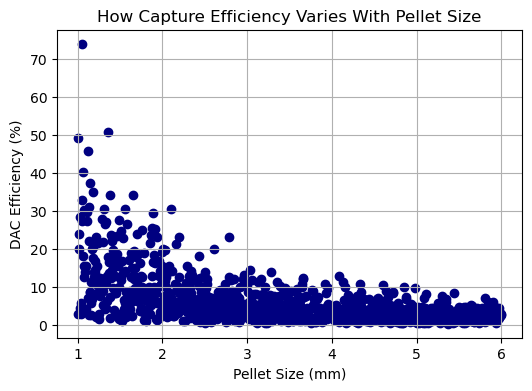

In [221]:
#PLot
plt.figure(figsize=(6, 4))
x=df_sim_lhs["pellet_diameter [mm]"]
y=df_sim_lhs["SCM_conversion_fraction"]*100
plt.scatter(x, y, color="navy")
plt.title("How Capture Efficiency Varies With Pellet Size")
plt.xlabel("Pellet Size (mm)")
plt.ylabel("DAC Efficiency (%)")
plt.grid(True)

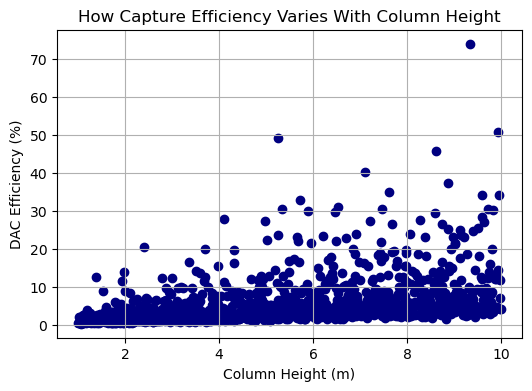

In [220]:
#PLot
plt.figure(figsize=(6, 4))
x=df_sim_lhs["DAC_column_height [m]"]
y=df_sim_lhs["SCM_conversion_fraction"]*100
plt.scatter(x, y, color="navy")
plt.title("How Capture Efficiency Varies With Column Height")
plt.xlabel("Column Height (m)")
plt.ylabel("DAC Efficiency (%)")
plt.grid(True)

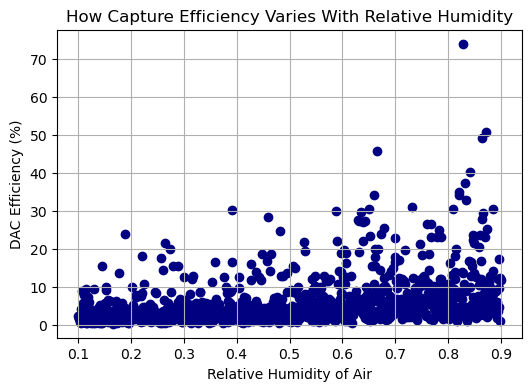

In [222]:
#PLot
plt.figure(figsize=(6, 4))
x=df_sim_lhs["RH_air"]
y=df_sim_lhs["SCM_conversion_fraction"]*100
plt.scatter(x, y, color="navy")
plt.title("How Capture Efficiency Varies With Relative Humidity")
plt.xlabel("Relative Humidity of Air")
plt.ylabel("DAC Efficiency (%)")
plt.grid(True)

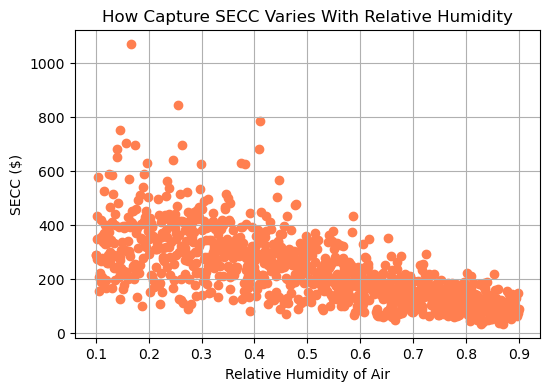

In [223]:
#PLot
plt.figure(figsize=(6, 4))
x=df_sim_lhs["RH_air"]
y=df_sim_lhs["SECC"]
plt.scatter(x, y, color="coral")
plt.title("How Capture SECC Varies With Relative Humidity")
plt.xlabel("Relative Humidity of Air")
plt.ylabel("SECC ($)")
plt.grid(True)

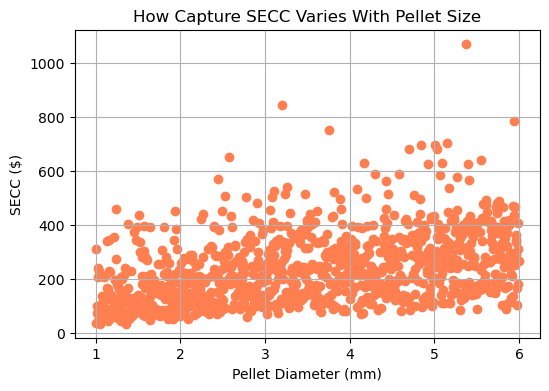

In [224]:
#PLot
plt.figure(figsize=(6, 4))
x=df_sim_lhs["pellet_diameter [mm]"]
y=df_sim_lhs["SECC"]
plt.scatter(x, y, color="coral")
plt.title("How Capture SECC Varies With Pellet Size")
plt.xlabel("Pellet Diameter (mm)")
plt.ylabel("SECC ($)")
plt.grid(True)

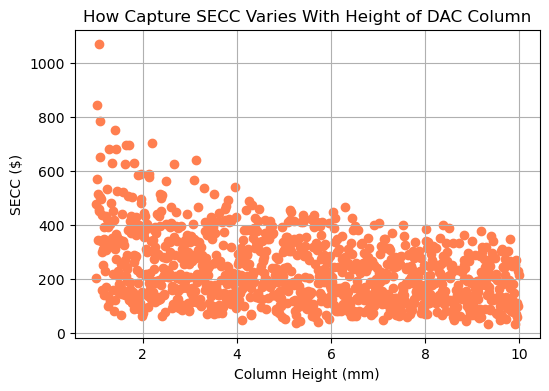

In [234]:
#PLot
plt.figure(figsize=(6, 4))
x=df_sim_lhs["DAC_column_height [m]"]
y=df_sim_lhs["SECC"]
plt.scatter(x, y, color="coral")
plt.title("How Capture SECC Varies With Height of DAC Column")
plt.xlabel("Column Height (mm)")
plt.ylabel("SECC ($)")
plt.grid(True)

In [148]:
df_pareto

,caco3_flow_rate [kmol/hr],calciner_temp [Deg C],pellet_moisture_frac,air_mol_flow_rate [kmol/hr],RH_air,DAC_column_height [m],pellet_diameter [mm],DAC_ambient_temp [Deg C],e_voidage,capture_efficiency_%,SECC_$
0,97.640591,947.125303,0.333040,8829.740466,0.898318,9.155514,1.019511,43.741866,0.355758,49.815746,-13.835405
1,97.645531,947.125303,0.333210,8829.728139,0.897813,9.165189,1.015949,43.742928,0.355754,49.815746,-13.835405
2,97.863788,919.904840,0.064531,7118.821754,0.870483,9.997187,1.049191,42.714769,0.353125,65.621880,10.950542
3,97.924051,919.904840,0.064555,7118.821754,0.870483,9.997187,1.049191,42.716989,0.353125,65.621880,10.950542
4,97.805738,947.120714,0.332511,8829.607155,0.899936,9.293540,1.001176,43.761773,0.355763,51.707901,-13.594645
...,...,...,...,...,...,...,...,...,...,...,...
995,97.892645,944.528936,0.064775,8915.727909,0.892891,9.984907,1.046664,43.769653,0.380992,59.395931,-10.678812
996,97.907560,944.886496,0.064511,7042.643146,0.892316,9.812477,1.048009,43.756998,0.381138,60.687401,-8.773365
997,97.659999,944.685925,0.266191,7044.871356,0.899489,9.969269,1.010119,43.779125,0.353143,63.423153,-3.091374
998,97.852300,944.900236,0.064534,7040.659885,0.891516,9.999207,1.021857,43.734374,0.381133,60.570187,-9.104662


In [ ]:
#COLOR CODES #FF5252, #1A237E, #FF5252, 

# 2.0 Surrogate ML results

In [162]:
import xgboost as xgb
import pandas as pd
from xgboost import XGBRegressor
import numpy as np
from pymoo.core.problem import Problem
import matplotlib.pyplot as plt

In [163]:
#Load specific energy cost per co2 consumed model (SECC)
DAC_SECC_model = XGBRegressor()
DAC_SECC_model.load_model("DAC_SECC_XGBmodel.json")

In [164]:
#load efficiency model
DAC_eff_model = xgb.XGBRegressor()
DAC_eff_model.load_model("DAC_efficiency_XGBmodel.json")


In [165]:
#Import wrangled data. This refers to data, cleaned, transformed right before feeding into surrogate model
wrangled_df = pd.read_csv("wrangled_DAC_simuation_results.csv")
wrangled_df

,caco3_flow_rate_kmol/hr,calciner_temp_DegC,pellet_moisture_frac,air_mol_flow_rate_kmol/hr,RH_air,DAC_column_height_m,pellet_diameter_mm,DAC_ambient_temp_DegC,e_voidage,capture_efficiency_%,SECC
0,97.514977,921.285152,0.493512,8833.277513,0.801022,4.919290,3.805631,21.742198,0.439079,6.523143,105.410825
1,31.906558,939.507047,0.333939,8082.465700,0.767765,2.624554,5.462603,34.839420,0.427176,1.830091,160.762374
2,66.419432,929.838273,0.426463,7335.719044,0.836021,1.900874,4.928280,24.921964,0.429412,2.375498,130.359369
3,99.038780,900.174052,0.347316,7315.145793,0.575318,9.355005,4.346817,38.664208,0.397470,6.788364,171.617326
4,98.462316,905.306138,0.112064,7753.304554,0.248262,2.872001,1.768148,41.269448,0.434394,3.421679,257.358216
...,...,...,...,...,...,...,...,...,...,...,...
1017,50.419064,931.582229,0.154068,7646.329962,0.871272,2.471474,2.465906,36.134729,0.415279,6.811835,80.651848
1018,20.367716,905.685989,0.261500,7404.025181,0.680243,8.748796,2.436164,15.250342,0.353304,10.254122,152.912984
1019,13.269341,943.607141,0.311672,8443.948358,0.492100,5.956748,2.016575,34.602614,0.440534,4.463911,228.219735
1020,24.203261,930.235680,0.242999,8127.516368,0.417274,5.403669,4.581640,40.993224,0.449766,1.717949,300.314345


In [166]:
X = wrangled_df.drop(columns=["capture_efficiency_%", "SECC"])

In [167]:
co_simulation_eff =  wrangled_df["capture_efficiency_%"]
surrogate_eff = DAC_eff_model.predict(X)

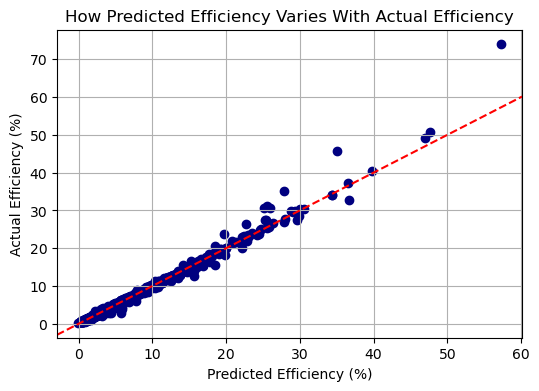

In [229]:
#PLot of DAC efficiency
plt.figure(figsize=(6, 4))
x=surrogate_eff
y=co_simulation_eff
plt.scatter(x, y, color="navy")
plt.title("How Predicted Efficiency Varies With Actual Efficiency")
plt.axline((0, 0), slope=1, color="red", linestyle="--")
plt.xlabel("Predicted Efficiency (%)")
plt.ylabel("Actual Efficiency (%)")
plt.grid(True)

In [192]:
co_simulation_SECC =  wrangled_df["SECC"]
surrogate_SECC = DAC_SECC_model.predict(X)

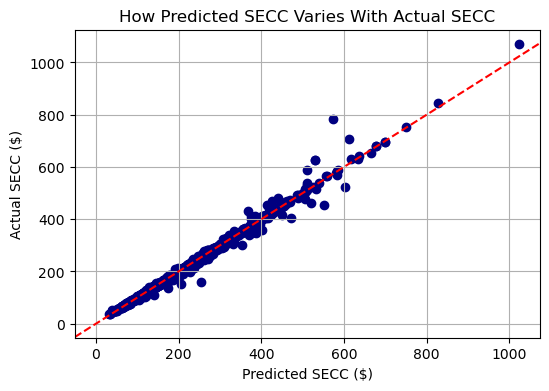

In [230]:
#PLot of DAC SECC
plt.figure(figsize=(6, 4))
x=surrogate_SECC
y=co_simulation_SECC
plt.scatter(x, y, color="navy")
plt.title("How Predicted SECC Varies With Actual SECC")
plt.axline((0, 0), slope=1, color="red", linestyle="--")
plt.xlabel("Predicted SECC ($)")
plt.ylabel("Actual SECC ($)")
plt.grid(True)